# Fase 2 - Modelos baseline: Elo y Dixon-Coles

## 1. Objetivo

Este notebook documenta **MODEL-01** (Elo dinámico), **MODEL-02** (Dixon-Coles), **MODEL-03** (W/D/L desde la matriz de marcadores) y **MODEL-04** (validación temporal estricta). El contrato final es `predict_lambdas(team_a, team_b, ctx)`: la Fase 3 consume tasas esperadas de gol sin conocer los detalles del ajuste.

La regla pedagógica es deliberada: las celdas de código solo importan e invocan funciones de producción; la matemática, decisiones e interpretación viven en Markdown.

## 2. Configuración reproducible

**What and why:** El notebook localiza la raíz del repositorio, carga los artefactos fechados más recientes y fija un estilo visual común. No reentrena modelos: consume exactamente los outputs auditables de la corrida `MODEL-04`.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.calibration import calibration_curve

from cdd_mundial.models import predict_lambdas
from cdd_mundial.models.dixon_coles import load_production_model, score_matrix, wdl_from_lambdas

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
assert (ROOT / 'pyproject.toml').exists(), 'Ejecuta el notebook dentro del repositorio'
os.chdir(ROOT)
sns.set_theme(style='whitegrid', context='notebook')
models_dir = Path('data/processed/models')
report_path = sorted(models_dir.glob('validation_report_*.json'))[-1]
predictions_path = sorted(models_dir.glob('holdout_predictions_*.parquet'))[-1]
print({'root': str(ROOT), 'report': report_path.name, 'predictions': predictions_path.name})

{'root': 'C:\\Users\\jesus\\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\\Documents\\CDD-MUNDIAL', 'report': 'validation_report_2026-06-12.json', 'predictions': 'holdout_predictions_2026-06-12.parquet'}


**Interpretation:** Los nombres fechados hacen explícita la versión evaluada. El notebook queda desacoplado del día concreto, pero siempre toma el último artefacto generado por el pipeline de validación.

## 3. Elo dinámico (MODEL-01)

**What and why:** La expectativa World Football Elo es

$$W_e = \frac{1}{10^{-dr/400}+1},$$

con $dr$ igual a la diferencia de rating y una ventaja local de +100 cuando `neutral=False`. La tabla K canónica WFE usada es 60/50/40/30/20; los torneos continentales reciben K=50 y las Nations Leagues clasificatorias K=40. La actualización usa el multiplicador de margen de la variante **FiveThirtyEight**, no la tabla discreta G de eloratings.net. Para empates el factor es 1.0: usar $\log(1)=0$ congelaría aproximadamente 22.7% del histórico. Partidos decididos en tiempo extra o penales actualizan como empate de 90 minutos, $W=0.5$.

Comparamos rangos porque el histórico custom arranca en 1000 y el snapshot externo vive cerca de 1500; el nivel absoluto no es identificable entre escalas, pero el orden sí.

,team_id,rank_custom,rank_external
0,spain,1,1
1,argentina,2,2
2,france,3,3
3,england,4,4
4,brazil,5,5


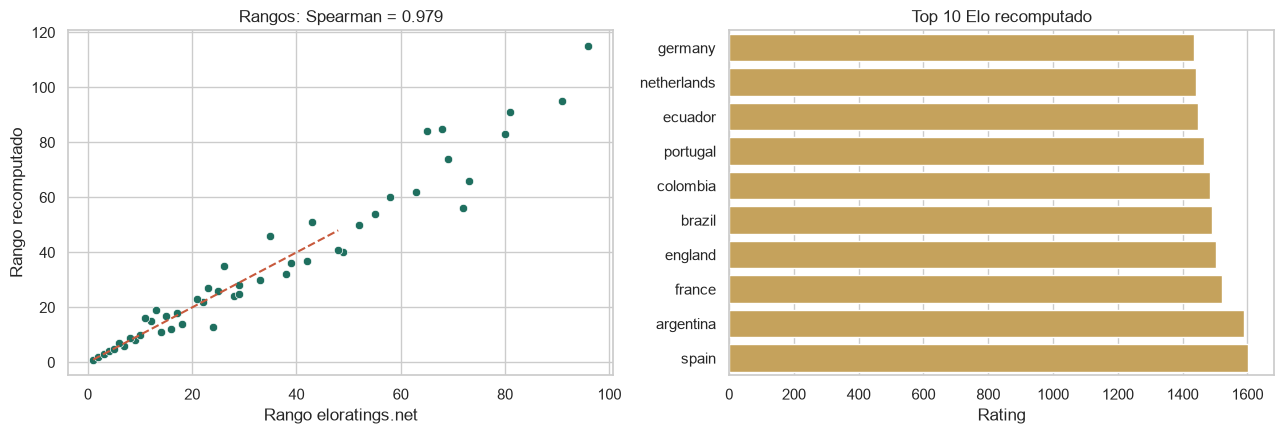

In [2]:
elo_custom = pd.read_parquet(models_dir / 'elo_ratings.parquet')
elo_external = pd.read_parquet('data/processed/elo_current.parquet')
comparison = elo_custom.merge(
    elo_external[['team_id', 'rank', 'elo_rating']],
    on='team_id',
    suffixes=('_custom', '_external'),
)
rho_rank = spearmanr(comparison['rank_custom'], comparison['rank_external']).statistic

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=comparison, x='rank_external', y='rank_custom', ax=axes[0], color='#1f6f5f')
axes[0].plot([1, 48], [1, 48], '--', color='#c85a3d')
axes[0].set(title=f'Rangos: Spearman = {rho_rank:.3f}', xlabel='Rango eloratings.net', ylabel='Rango recomputado')
top10 = elo_custom.nsmallest(10, 'rank').sort_values('rank', ascending=False)
sns.barplot(data=top10, x='elo_rating', y='team_id', ax=axes[1], color='#d6a84b')
axes[1].set(title='Top 10 Elo recomputado', xlabel='Rating', ylabel='')
plt.tight_layout()
comparison[['team_id', 'rank_custom', 'rank_external']].head()

**Interpretation:** La correlación de rangos supera ampliamente el gate 0.9. Las diferencias residuales son esperables: nuestro Elo usa cold-start 1000, tabla K y semántica de 90 minutos documentadas, mientras el snapshot externo incorpora su propia historia y escala.

## 4. Dixon-Coles: dependencia en marcadores bajos

**What and why:** Dixon-Coles corrige la independencia de dos Poisson en los cuatro marcadores bajos:

$$P(X=x,Y=y)=\tau_{\lambda,\mu,\rho}(x,y)\,\mathrm{Poisson}(x;\lambda)\,\mathrm{Poisson}(y;\mu).$$

$$\tau(x,y)=\begin{cases}
1-\lambda\mu\rho &(0,0)\\
1+\lambda\rho &(0,1)\\
1+\mu\rho &(1,0)\\
1-\rho &(1,1)\\
1 &\text{otro caso.}
\end{cases}$$

Las intensidades siguen $\log\lambda=c+att_i-def_j+\gamma\,I[local]$ y $\log\mu=c+att_j-def_i$. La log-likelihood ponderada es

$$\ell=\sum_m w_m[\log\tau+x\log\lambda-\lambda+y\log\mu-\mu],\qquad w_m=e^{-\xi\Delta t}.$$

El gradiente de `att_i` acumula términos $(x-\lambda)$ en los partidos del equipo; $\log\tau$ aporta derivadas adicionales solo cuando ambos marcadores son menores o iguales a 1. La identificabilidad se impone con $\sum att=\sum def=0$ mediante penalización suave y $\rho$ queda acotado.

La aritmética del decaimiento es $t_{1/2}=\ln(2)/\xi$: `0.0018/día` equivale a 385 días (aprox. 1.05 años), mientras `0.00095/día` equivale a unos 730 días (aprox. 2 años). El mini-grid resolvió la discrepancia con evidencia holdout.

,team_a,team_b,neutral,lambda_a,lambda_b,p_win_a,p_draw,p_win_b,modal_score
0,argentina,mexico,True,1.5131,0.4721,0.6264,0.2658,0.1078,1-0
1,canada,bosnia-and-herzegovina,True,1.3141,0.7160,0.5022,0.3015,0.1963,1-0
2,mexico,canada,False,1.3023,0.8744,0.4576,0.2993,0.2431,1-0
3,spain,france,True,1.4579,1.0966,0.4469,0.2758,0.2773,1-1


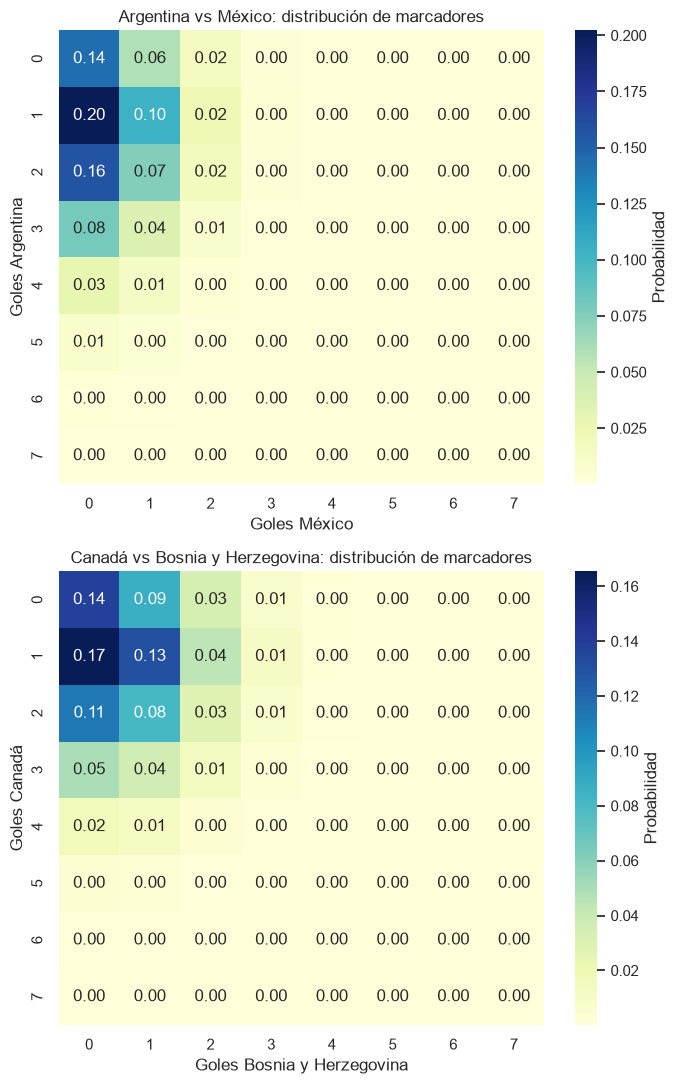

In [3]:
model = load_production_model()
ctx_neutral = {'neutral': True, 'date': pd.Timestamp('2026-06-15'), 'tournament_type': 'FIFA World Cup'}
ctx_host = {'neutral': False, 'date': pd.Timestamp('2026-06-15'), 'tournament_type': 'FIFA World Cup'}
example_inputs = [
    ('argentina', 'mexico', True, ctx_neutral),
    ('canada', 'bosnia-and-herzegovina', True, ctx_neutral),
    ('mexico', 'canada', False, ctx_host),
    ('spain', 'france', True, ctx_neutral),
]
example_rows = []
for team_a, team_b, neutral, context in example_inputs:
    lam, mu = predict_lambdas(team_a, team_b, context)
    p_win, p_draw, p_loss = wdl_from_lambdas(lam, mu, model.rho)
    match_matrix = score_matrix(lam, mu, model.rho, max_goals=7)
    modal_a, modal_b = np.unravel_index(match_matrix.argmax(), match_matrix.shape)
    example_rows.append((team_a, team_b, neutral, lam, mu, p_win, p_draw, p_loss, f'{modal_a}-{modal_b}'))
examples = pd.DataFrame(
    example_rows,
    columns=['team_a', 'team_b', 'neutral', 'lambda_a', 'lambda_b', 'p_win_a', 'p_draw', 'p_win_b', 'modal_score'],
)

arg_lam, arg_mu = predict_lambdas('argentina', 'mexico', ctx_neutral)
can_lam, can_mu = predict_lambdas('canada', 'bosnia-and-herzegovina', ctx_neutral)
arg_matrix = score_matrix(arg_lam, arg_mu, model.rho, max_goals=7)
can_matrix = score_matrix(can_lam, can_mu, model.rho, max_goals=7)
fig, axes = plt.subplots(2, 1, figsize=(7, 11))
sns.heatmap(arg_matrix, cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'Probabilidad'}, ax=axes[0])
axes[0].set(title='Argentina vs México: distribución de marcadores', xlabel='Goles México', ylabel='Goles Argentina')
sns.heatmap(can_matrix, cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'Probabilidad'}, ax=axes[1])
axes[1].set(title='Canadá vs Bosnia y Herzegovina: distribución de marcadores', xlabel='Goles Bosnia y Herzegovina', ylabel='Goles Canadá')
plt.tight_layout()
examples.round(4)

**Interpretation:** `lambda_a` y `lambda_b` son medias de gol, no probabilidades. La tabla transforma esas tasas en victoria del equipo A, empate, victoria del equipo B y marcador modal. El segundo heatmap muestra la simulación neutral Canadá-Bosnia y Herzegovina inmediatamente debajo de Argentina-México. La masa se concentra en marcadores bajos; `gamma` eleva únicamente la intensidad del lado anfitrión cuando `neutral=False`, y la corrección $\rho$ redistribuye masa entre 0-0, 0-1, 1-0 y 1-1.

## 5. W/D/L y sanidad de empates (MODEL-03)

**What and why:** Las probabilidades 1/X/2 se obtienen sumando la matriz de marcadores: triángulo inferior, diagonal y triángulo superior. El empate no sale de un logistic sobre Elo. Para equipos de fuerza semejante en cancha neutral esperamos una probabilidad de empate cercana a 24-28%.

In [4]:
similar_pairs = [('germany', 'belgium'), ('brazil', 'netherlands'), ('france', 'germany')]
draw_rows = []
for team_a, team_b in similar_pairs:
    lam, mu = predict_lambdas(team_a, team_b, ctx_neutral)
    p_win, p_draw, p_loss = wdl_from_lambdas(lam, mu, model.rho)
    draw_rows.append((team_a, team_b, lam, mu, p_win, p_draw, p_loss))
draw_check = pd.DataFrame(
    draw_rows,
    columns=['team_a', 'team_b', 'lambda_a', 'lambda_b', 'p_win', 'p_draw', 'p_loss'],
)
assert draw_check['p_draw'].between(0.24, 0.28).all()
draw_check

,team_a,team_b,lambda_a,lambda_b,p_win,p_draw,p_loss
0,germany,belgium,1.471453,1.468683,0.371082,0.259065,0.369853
1,brazil,netherlands,1.591758,1.226001,0.451922,0.260684,0.287394
2,france,germany,1.553572,1.301955,0.425793,0.261255,0.312951


**Interpretation:** La banda 24-28% es un check de escala, no una restricción dura para cada cruce. Cuando las tasas son parecidas, la diagonal de la matriz concentra más masa; si una selección domina, esa masa migra hacia victorias y el empate puede salir de la banda.

## 6. Validación temporal y gate D-13 (MODEL-04)

**What and why:** Cada torneo se predice con un modelo ajustado solo con partidos anteriores a su kickoff. El mini-grid compara $\xi\in\{0.00095,0.0018\}$ por log-loss medio. Después se reportan log-loss, Brier y RPS contra dos referencias pre-registradas: uniforme y solo-Elo. El baseline de ranking FIFA quedó fuera por decisión del Director al no existir una serie point-in-time ingerida.

log_loss                        brier                   \
model    dixon_coles solo_elo uniform dixon_coles solo_elo uniform   
holdout                                                              
copa2024      0.8839   0.8618  1.0986      0.5193   0.5046  0.6667   
euro2024      0.9914   1.0293  1.0986      0.5936   0.6169  0.6667   
wc2018        0.9529   0.9797  1.0986      0.5641   0.5819  0.6667   
wc2022        1.0406   1.0612  1.0986      0.6032   0.6245  0.6667   

                 rps                   
model    dixon_coles solo_elo uniform  
holdout                                
copa2024      0.1609   0.1552  0.2309  
euro2024      0.1876   0.1957  0.2222  
wc2018        0.1987   0.2083  0.2439  
wc2022        0.2134   0.2262  0.2387

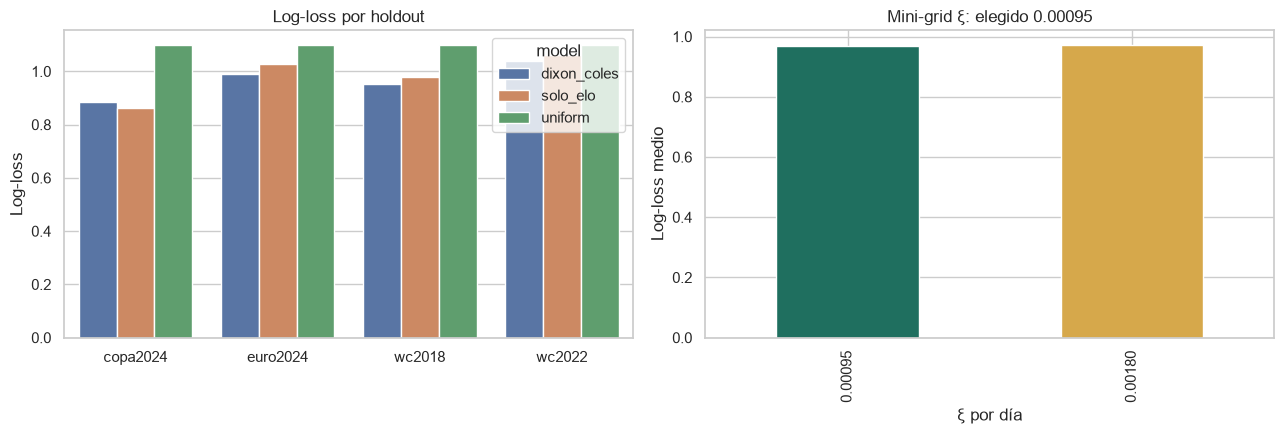

In [5]:
report = json.loads(report_path.read_text(encoding='utf-8'))
metric_rows = []
for holdout, detail in report['per_holdout'].items():
    for model_name, metrics in detail['metrics'].items():
        metric_rows.append({'holdout': holdout, 'model': model_name, **metrics})
metrics = pd.DataFrame(metric_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=metrics, x='holdout', y='log_loss', hue='model', ax=axes[0])
axes[0].set(title='Log-loss por holdout', xlabel='', ylabel='Log-loss')
xi_scores = pd.DataFrame(report['xi_search']).T
xi_scores.mean(axis=1).plot(kind='bar', ax=axes[1], color=['#1f6f5f', '#d6a84b'])
axes[1].set(title=f"Mini-grid ξ: elegido {report['chosen_xi']}", xlabel='ξ por día', ylabel='Log-loss medio')
plt.tight_layout()
metrics.pivot(index='holdout', columns='model', values=['log_loss', 'brier', 'rps']).round(4)

**Interpretation:** El gate pasó: Dixon-Coles obtiene log-loss medio 0.9672, frente a 0.9830 de solo-Elo y 1.0986 del uniforme. La victoria media no implica dominar cada torneo: en Copa 2024 solo-Elo fue mejor. Esa heterogeneidad es precisamente la razón para conservar los cuatro holdouts y reportar el resultado completo.

## 7. Reliability diagram

**What and why:** Un modelo puede tener buen log-loss y aun estar mal calibrado. `calibration_curve` compara, one-vs-rest, la probabilidad media predicha con la frecuencia observada para victoria local, empate y victoria visitante en las 211 predicciones Dixon-Coles de los cuatro holdouts.

{'criterion': 'mean log-loss over 4 holdouts vs uniform and solo_elo',
 'mean_log_loss': {'dixon_coles': 0.9671839414004801,
  'solo_elo': 0.9830166784963363,
  'uniform': 1.0986122886681098},
 'note': 'FIFA-ranking baseline excluded per Director decision (OQ3) - optional post-phase stretch',
 'passed': True}

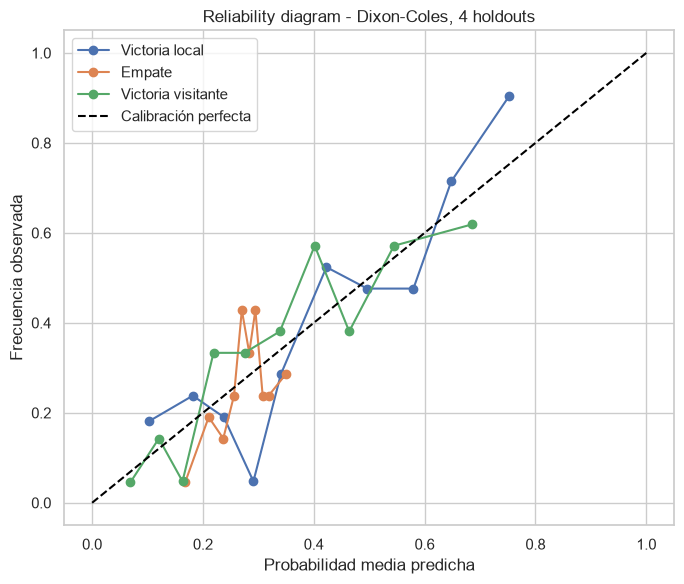

In [6]:
predictions = pd.read_parquet(predictions_path)
dc = predictions[predictions['model'] == 'dixon_coles'].copy()
probability_columns = ['p_home_win', 'p_draw', 'p_away_win']
labels = ['Victoria local', 'Empate', 'Victoria visitante']

plt.figure(figsize=(7, 6))
for class_index, (column, label) in enumerate(zip(probability_columns, labels, strict=True)):
    observed = (dc['outcome_idx'].to_numpy() == class_index).astype(int)
    fraction_positive, mean_predicted = calibration_curve(
        observed,
        dc[column].to_numpy(),
        n_bins=10,
        strategy='quantile',
    )
    plt.plot(mean_predicted, fraction_positive, marker='o', label=label)
plt.plot([0, 1], [0, 1], '--', color='black', label='Calibración perfecta')
plt.xlabel('Probabilidad media predicha')
plt.ylabel('Frecuencia observada')
plt.title('Reliability diagram - Dixon-Coles, 4 holdouts')
plt.legend()
plt.tight_layout()
report['gate']

**Interpretation:** Las curvas cercanas a la diagonal indican honestidad probabilística; separaciones sistemáticas revelan sobreconfianza o subconfianza. Con 211 partidos y tres clases, cada bin tiene incertidumbre apreciable: el diagrama es diagnóstico, no una licencia para calibrar agresivamente con pocos datos. Si D-13 hubiera fallado, el resultado se habría persistido igualmente y la Fase 5 habría intentado mejorar el baseline sin reescribir la evidencia.

## 8. Cierre

La Fase 2 deja congelado el contrato D-09 y un modelo de producción fechado. La Fase 3 recibe únicamente $(\lambda_a,\lambda_b)$ para simular marcadores y torneo. La Fase 5 reutilizará `elo_history.parquet`, las predicciones holdout y las tasas Dixon-Coles bajo el mismo protocolo temporal. El valor del baseline no es solo haber pasado el gate: es que el proceso, los cortes y los artefactos permiten reproducir por qué lo pasó.